# Revenue Imputing and Nowcasting

In [1]:
# Load libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial

In [2]:
# Set working directory to project root
import importlib
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
# Import utilities from migrated utils package
from utils import forecast_utils, model_utils, test_utils

importlib.reload(forecast_utils)
importlib.reload(model_utils)
importlib.reload(test_utils)

from utils.forecast_utils import (
    add_time_columns,
    add_quality_flags,
    add_lag_features,
    evaluate_predictions,
    prepare_eval_frames,
    fit_group_average_lookup,
    apply_group_average_lookup,
    fit_epsr_lookup,
    apply_epsr_lookup,
    run_distribution_backtest,
)

from utils.model_utils import (
    split_time_holdout,
    fit_predict_xgb_refined,
    fit_predict_lgbm_refined,
    fit_predict_knn_refined,
    fit_predict_lag_hier_nowcast,
)

from utils.test_utils import (
    group_avg_fit_predict,
    naive_fit_predict,
    epsr_fit_predict
)

## 1. Baselines: Group Average, Naive
As baselines, we consider two rules:

- **Group Average Baseline**: This method calculates the average target value for each group defined by `GROUP_COLS` and uses it as the prediction for missing or zero values.
- **Naive Baseline Rule**: This method uses the most recent non-missing value within each group as the prediction for the current period.

In [4]:
df = pd.read_csv("../data/merged_data.csv", index_col=False)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               2000 non-null   str    
 1   business_unit       2000 non-null   str    
 2   territory_name      2000 non-null   str    
 3   dsp                 2000 non-null   str    
 4   total_streams       2000 non-null   int64  
 5   total_gross_amount  1812 non-null   float64
 6   is_na               2000 non-null   int64  
 7   is_zero             2000 non-null   int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 125.1 KB


In [5]:
# Define global constants
TARGET_COL = 'total_gross_amount'
STREAM_COL = 'total_streams'
GROUP_COLS = ['business_unit', 'territory_name', 'dsp']
CATEGORICAL_COLS = ['business_unit', 'territory_name', 'dsp']
EXCLUDED_EVAL_MONTHS = ['2025-09', '2025-10']  # Excluded because dominated by NaN and zero values

# Cohort-aware quality-flag settings
LOW_REVENUE_THRESHOLD = 99.0
LOW_RATIO_THRESHOLD = 0.20

In [6]:
# Quick check: where are missing/zero targets concentrated?
month_missing_profile = (
    df.assign(
        month=pd.to_datetime(df['month']),
        target_flag=((df['is_na'] == 1) | (df['is_zero'] == 1)).astype(int)
    )
    .groupby(df['month'].astype(str))
    .agg(total_rows=('target_flag', 'size'), target_rows=('target_flag', 'sum'))
    .reset_index()
    .rename(columns={'month': 'month_str'})
)

# Calculate the share of missing/zero targets for each month
month_missing_profile['target_share'] = month_missing_profile['target_rows'] / month_missing_profile['total_rows']
month_missing_profile

,month_str,total_rows,target_rows,target_share
0,2025-01-01,200,2,0.01
1,2025-02-01,200,2,0.01
2,2025-03-01,200,2,0.01
3,2025-04-01,200,2,0.01
4,2025-05-01,200,2,0.01
5,2025-06-01,200,2,0.01
6,2025-07-01,200,2,0.01
7,2025-08-01,200,10,0.05
8,2025-09-01,200,82,0.41
9,2025-10-01,200,180,0.90


In [7]:
# Study the distribution of NA, zero, and cohort-aware quality flags
df = add_quality_flags(df)

# Count flags by business_unit, territory_name, and dsp
flag_counts = df.groupby(['business_unit', 'territory_name', 'dsp'])[[
    'is_na', 'is_zero', 'quality_flag_low_revenue_high_streams'
 ]].sum().reset_index()

# Plot stacked distributions across multiple dimensions
plot_dims = [
    ('business_unit', 'Business Unit'),
    ('territory_name', 'Territory'),
    ('dsp', 'DSP'),
    ('month', 'Month')
]

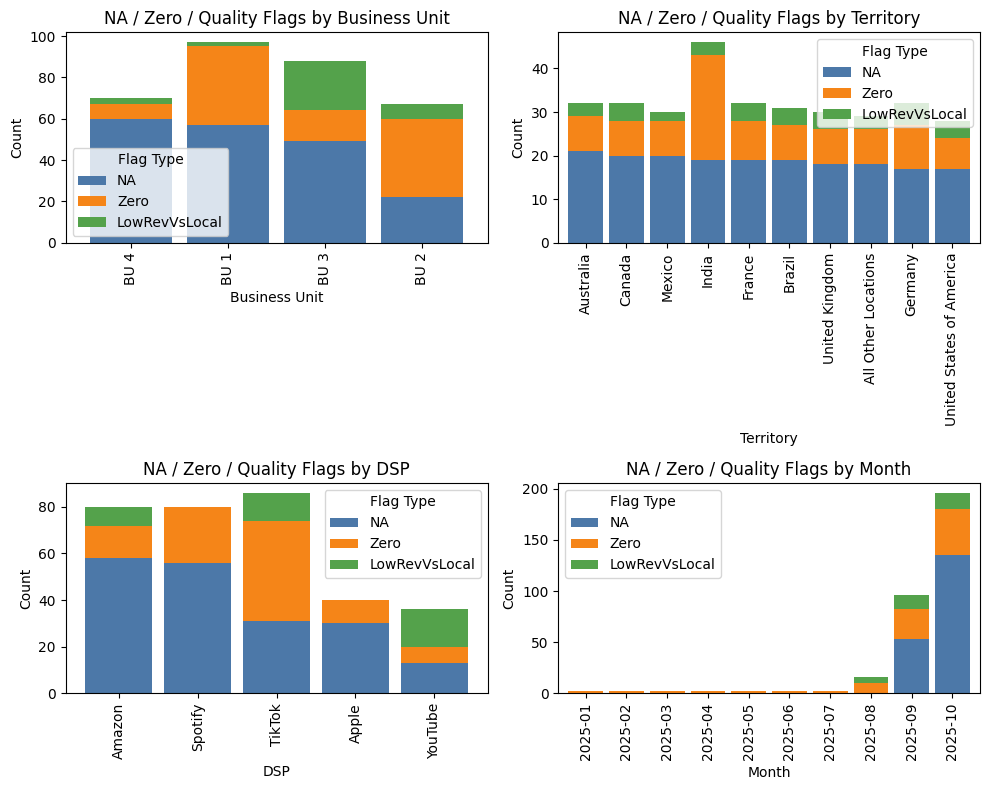

Cohort-aware quality-flag rows: 36


In [8]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plot_dims):
    if col == 'month':
        agg = (
            df.assign(month=pd.to_datetime(df['month']).dt.to_period('M').astype(str))
              .groupby('month')[['is_na', 'is_zero', 'quality_flag_low_revenue_high_streams']]
              .sum()
              .sort_index()
        )
    else:
        agg = (
            flag_counts.groupby(col)[['is_na', 'is_zero', 'quality_flag_low_revenue_high_streams']]
            .sum()
            .sort_values(['is_na', 'is_zero', 'quality_flag_low_revenue_high_streams'], ascending=False)
        )
        if col in ['territory_name', 'dsp']:
            agg = agg.head(15)  # keep readable

    agg.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=['#4C78A8', '#F58518', '#54A24B'],
        width=0.85
    )
    ax.set_title(f'NA / Zero / Quality Flags by {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(title='Flag Type', labels=['NA', 'Zero', 'LowRevVsLocal'])

plt.tight_layout()
plt.show()

print('Cohort-aware quality-flag rows:', int(df['quality_flag_low_revenue_high_streams'].sum()))

In [9]:
# Baseline 1: Pure per-group average imputation/nowcasting
work_df, known_all_df, known_eval_df, target_df = prepare_eval_frames(
    data=df,
    stream_col=STREAM_COL,
    excluded_months=EXCLUDED_EVAL_MONTHS
)

group_avg_lookup = fit_group_average_lookup(
    train_known=known_all_df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL
)

group_avg_eval = apply_group_average_lookup(
    score_data=known_eval_df,
    lookup=group_avg_lookup,
    group_cols=GROUP_COLS
)
group_avg_eval = group_avg_eval.rename(columns={'pred': 'group_avg_baseline'})

group_avg_metrics = evaluate_predictions(
    data=group_avg_eval,
    target_col=TARGET_COL,
    pred_col='group_avg_baseline',
    label='Group Average Baseline',
)

In [10]:
# Store baseline prediction on full dataframe
group_avg_all = apply_group_average_lookup(
    score_data=work_df,
    lookup=group_avg_lookup,
    group_cols=GROUP_COLS
)
df = work_df.copy()
df['group_avg_baseline'] = group_avg_all['pred'].values

metric_df = pd.DataFrame([group_avg_metrics])[['Method', 'MAE', 'WMAPE', 'Rows']]

metric_df

,Method,MAE,WMAPE,Rows
0,Group Average Baseline,6584.159686,0.111197,1576


In [11]:
# Baseline 2: Naive rule 
naive_df = add_time_columns(df).sort_values(GROUP_COLS + ['month']).copy()
naive_df['naive_baseline'] = naive_df.groupby(GROUP_COLS)[TARGET_COL].shift(1)

known_mask = (naive_df['is_na'] == 0) & (naive_df['is_zero'] == 0) & (naive_df[STREAM_COL] > 0)
included_mask = ~naive_df['month_str'].isin(EXCLUDED_EVAL_MONTHS)

naive_eval = naive_df.loc[known_mask & included_mask & naive_df['naive_baseline'].notna()].copy()
naive_metrics = evaluate_predictions(
    data=naive_eval,
    target_col=TARGET_COL,
    pred_col='naive_baseline',
    label='Naive Baseline',
)

metric_df = pd.concat([metric_df, pd.DataFrame([naive_metrics])], ignore_index=True)
metric_df.sort_values('WMAPE')

,Method,MAE,WMAPE,Rows
1,Naive Baseline,5571.952830,0.092685,1378
0,Group Average Baseline,6584.159686,0.111197,1576


## 2. Model Comparison
In this section, we compare machine-learning models and the lag-aware nowcast method using the same data split and metrics.
The goal is simple: find methods that are both accurate and stable before final rule selection.

In [12]:
# Build lag features once, then create train/eval pools for all model methods
lag_df = add_lag_features(
    data=df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    lag=1
)
lag_df = add_quality_flags(lag_df)

included_mask = ~lag_df['month_str'].isin(EXCLUDED_EVAL_MONTHS)
known_mask = (lag_df['is_na'] == 0) & (lag_df['is_zero'] == 0) & (lag_df[STREAM_COL] > 0)
target_mask = (lag_df['is_na'] == 1) | (lag_df['is_zero'] == 1)
quality_flag_mask = lag_df['quality_flag_low_revenue_high_streams'] == 1

model_known_eval = lag_df.loc[known_mask & included_mask].copy()
model_target_rows = lag_df.loc[target_mask | quality_flag_mask].copy()

In [13]:
# Keep names simple and business-readable
model_registry = [
    ('XGBoost', partial(fit_predict_xgb_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('LightGBM', partial(fit_predict_lgbm_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('KNN', partial(fit_predict_knn_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('Lag-Aware Hierarchical Nowcast', partial(
        fit_predict_lag_hier_nowcast,
        group_cols=GROUP_COLS,
        stream_col=STREAM_COL,
        target_col=TARGET_COL,
    )),
]

In [14]:
model_rows = []
for model_name, fit_predict_fn in model_registry:
    train_df, val_df = split_time_holdout(model_known_eval)
    val_df = val_df.copy()
    val_df['model_pred'] = fit_predict_fn(train_df, val_df)

    model_metrics = evaluate_predictions(
        data=val_df,
        target_col=TARGET_COL,
        pred_col='model_pred',
        label=model_name,
    )
    model_rows.append(model_metrics)

In [15]:
# Write each model prediction back to the main dataframe
pred_col_map = {
    'XGBoost': 'xgb_pred',
    'LightGBM': 'lgbm_pred',
    'KNN': 'knn_pred',
    'Lag-Aware Hierarchical Nowcast': 'lag_hier_nowcast_pred',
}

for model_name, fit_predict_fn in model_registry:
    pred_col = pred_col_map[model_name]
    scored_target = model_target_rows.copy()
    scored_target[pred_col] = fit_predict_fn(model_known_eval, scored_target)
    df[pred_col] = np.nan
    df.loc[scored_target.index, pred_col] = scored_target[pred_col].values

# Keep metric table idempotent when cells are re-run
model_method_names = [name for name, _ in model_registry]
metric_df = metric_df[~metric_df['Method'].isin(model_method_names)].copy()
metric_df = pd.concat([metric_df, pd.DataFrame(model_rows)], ignore_index=True)
metric_df = metric_df.sort_values('WMAPE').reset_index(drop=True)

metric_df

,Method,MAE,WMAPE,Rows
0,Lag-Aware Hierarchical Nowcast,5456.681399,0.084559,190
1,Naive Baseline,5571.952830,0.092685,1378
2,Group Average Baseline,6584.159686,0.111197,1576
3,XGBoost,10055.477203,0.155824,190
4,LightGBM,12255.826339,0.189921,190
5,KNN,16248.801155,0.251798,190


## 3. EPSR Reference
EPSR is kept as a simple, transparent reference method.
It helps us judge whether more complex models are actually adding value.

In [16]:
# EPSR reference method
epsr_lookup = fit_epsr_lookup(
    train_known=known_all_df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL
)

# Apply EPSR lookup to evaluation set
epsr_eval = apply_epsr_lookup(
    score_data=known_eval_df,
    lookup=epsr_lookup,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL
)
epsr_eval = epsr_eval.rename(columns={'pred': 'epsr_baseline'})

# Evaluate EPSR predictions in the same cell to avoid run-order issues
epsr_metrics = evaluate_predictions(
    data=epsr_eval,
    target_col=TARGET_COL,
    pred_col='epsr_baseline',
    label='EPSR',
)

In [17]:
# Store EPSR predictions on the full dataframe for fair comparison
epsr_all = apply_epsr_lookup(
    score_data=df,
    lookup=epsr_lookup,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL
)
df['epsr_baseline'] = epsr_all['pred'].values

# Keep metric table idempotent when cells are re-run
metric_df = metric_df[metric_df['Method'] != 'EPSR'].copy()
metric_df = pd.concat([metric_df, pd.DataFrame([epsr_metrics])], ignore_index=True)
metric_df.sort_values('WMAPE')

,Method,MAE,WMAPE,Rows
6,EPSR,4880.511846,0.082425,1576
0,Lag-Aware Hierarchical Nowcast,5456.681399,0.084559,190
1,Naive Baseline,5571.952830,0.092685,1378
2,Group Average Baseline,6584.159686,0.111197,1576
3,XGBoost,10055.477203,0.155824,190
4,LightGBM,12255.826339,0.189921,190
5,KNN,16248.801155,0.251798,190


## 4. Distribution-Aware Stress Test

- This test simulates production-like missingness by matching the month pattern of real missing/zero rows.
- We repeat the process 30 times so the decision is based on stability, not one lucky split.

In [18]:
# Distribution-aware stress test across baselines and main strategies
stress_source = add_lag_features(
    data=df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    lag=1
)

stress_work, stress_known_all, stress_known_eval, stress_target = prepare_eval_frames(
    data=stress_source,
    stream_col=STREAM_COL,
    excluded_months=EXCLUDED_EVAL_MONTHS
)

stress_target_eval = stress_target[~stress_target['month_str'].isin(EXCLUDED_EVAL_MONTHS)].copy()

In [19]:
# Stress-test registry with simple and consistent model names
stress_registry = [
    ('Group Average', partial(
        group_avg_fit_predict,
        group_cols=GROUP_COLS,
        target_col=TARGET_COL,
    )),
    ('Naive', partial(
        naive_fit_predict,
        group_cols=GROUP_COLS,
        target_col=TARGET_COL,
    )),
    ('EPSR', partial(
        epsr_fit_predict,
        group_cols=GROUP_COLS,
        target_col=TARGET_COL,
        stream_col=STREAM_COL,
    )),
    ('Lag-Aware Hierarchical Nowcast', partial(
        fit_predict_lag_hier_nowcast,
        group_cols=GROUP_COLS,
        stream_col=STREAM_COL,
        target_col=TARGET_COL,
    )),
    ('XGBoost', partial(fit_predict_xgb_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('LightGBM', partial(fit_predict_lgbm_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
    ('KNN', partial(fit_predict_knn_refined, categorical_cols=CATEGORICAL_COLS, stream_col=STREAM_COL)),
]

In [20]:
# Run distribution-aware backtest for each method and aggregate results
overall_parts = []
for model_name, fit_predict_fn in stress_registry:
    overall_df, _ = run_distribution_backtest(
        known_pool=stress_known_eval,
        target_pool=stress_target_eval,
        fit_predict_fn=fit_predict_fn,
        target_col=TARGET_COL,
        n_repeats=30,
        random_state=42,
        model_name=model_name,
    )
    overall_parts.append(overall_df)

stress_overall = pd.concat(overall_parts, ignore_index=True)
stress_summary = (
    stress_overall.groupby('Model')['WMAPE']
    .agg(mean='mean', std='std', p10=lambda s: s.quantile(0.10), p50='median', p90=lambda s: s.quantile(0.90))
    .reset_index()
    .sort_values('mean')
)

print(f"Stress-test repeats per model: {stress_overall['repeat'].nunique()}")
stress_summary

Stress-test repeats per model: 30


,Model,mean,std,p10,p50,p90
3,Lag-Aware Hierarchical Nowcast,0.100222,0.051660,0.050119,0.094646,0.144956
0,EPSR,0.101979,0.052042,0.050612,0.096408,0.146416
1,Group Average,0.129900,0.048650,0.078474,0.129154,0.185543
4,LightGBM,0.166645,0.124224,0.069138,0.131530,0.314059
6,XGBoost,0.176132,0.119028,0.075238,0.145044,0.288367
5,Naive,0.187067,0.141891,0.076041,0.134553,0.372277
2,KNN,0.273835,0.103885,0.162851,0.262864,0.420568


In [21]:
# Rank models by stress performance and compare each method to EPSR
epsr_mean = stress_summary.loc[stress_summary['Model'] == 'EPSR', 'mean'].iloc[0]

stress_rank_table = stress_summary.copy()
stress_rank_table['delta_vs_epsr'] = stress_rank_table['mean'] - epsr_mean
stress_rank_table = stress_rank_table.sort_values('mean')

stress_rank_table[['Model', 'mean', 'p50', 'p90', 'delta_vs_epsr']]

,Model,mean,p50,p90,delta_vs_epsr
3,Lag-Aware Hierarchical Nowcast,0.100222,0.094646,0.144956,-0.001757
0,EPSR,0.101979,0.096408,0.146416,0.000000
1,Group Average,0.129900,0.129154,0.185543,0.027921
4,LightGBM,0.166645,0.131530,0.314059,0.064666
6,XGBoost,0.176132,0.145044,0.288367,0.074153
5,Naive,0.187067,0.134553,0.372277,0.085088
2,KNN,0.273835,0.262864,0.420568,0.171856


## 5. Final Rule Selection

We select the final nowcasting rule using stress-test performance and stability.
- Selected final rule: **Lag-Aware Hierarchical Nowcast**
- Reference method: **EPSR**

In [22]:
# Select the final production rule based on stress-test ranking
final_rule_col = 'lag_hier_nowcast_pred'
final_rule_name = 'Lag-Aware Hierarchical Nowcast'

# Side-by-side view: selected final rule vs EPSR reference
final_rule_summary = stress_rank_table[
    stress_rank_table['Model'].isin([final_rule_name, 'EPSR'])
][['Model', 'mean', 'p50', 'p90', 'delta_vs_epsr']].sort_values('mean')

final_rule_summary

,Model,mean,p50,p90,delta_vs_epsr
3,Lag-Aware Hierarchical Nowcast,0.100222,0.094646,0.144956,-0.001757
0,EPSR,0.101979,0.096408,0.146416,0.000000


## 6. Final Deliverable Dataset (with Cohort-Aware Quality Flags)
In addition to missing/zero rows, we automatically flag suspicious low-revenue rows using local cohort comparison (territory + DSP, with DSP/global fallback).
Flagged rows are nowcasted to improve data quality, and the reason is recorded in the output.

In [23]:
# Build final deliverable with quality-flag correction nowcasting
final_imputed_df = add_quality_flags(df)

# 1) Original nowcast target: missing or zero revenue
target_mask = (final_imputed_df['is_na'] == 1) | (final_imputed_df['is_zero'] == 1)

# 2) Strict quality-flag target: single/two-digit revenue + large streams
quality_flag_mask = final_imputed_df['quality_flag_low_revenue_high_streams'] == 1

# Combined rows to nowcast
rows_to_nowcast = target_mask | quality_flag_mask

In [24]:
# Train lag-aware nowcast on cleaner known rows (exclude target and quality-flag rows)
lag_source = add_lag_features(
    data=final_imputed_df,
    group_cols=GROUP_COLS,
    target_col=TARGET_COL,
    stream_col=STREAM_COL,
    lag=1
)
lag_source = add_quality_flags(lag_source)

train_mask_clean = (
    (lag_source['is_na'] == 0)
    & (lag_source['is_zero'] == 0)
    & (lag_source[STREAM_COL] > 0)
    & (lag_source['quality_flag_low_revenue_high_streams'] == 0)
)
train_clean_df = lag_source.loc[train_mask_clean].copy()
score_nowcast_df = lag_source.loc[rows_to_nowcast].copy()

In [25]:
# Generate quality-improved nowcasts
score_nowcast_df['nowcast_pred'] = fit_predict_lag_hier_nowcast(
    train_data=train_clean_df,
    score_data=score_nowcast_df,
    group_cols=GROUP_COLS,
    stream_col=STREAM_COL,
    target_col=TARGET_COL,
)

In [26]:
# Keep one final revenue field
final_imputed_df['filled_revenue'] = final_imputed_df[TARGET_COL]
final_imputed_df.loc[score_nowcast_df.index, 'filled_revenue'] = score_nowcast_df['nowcast_pred'].values

# Human-readable quality and nowcast labeling
final_imputed_df['value_status'] = np.where(rows_to_nowcast, 'nowcasted', 'actual')
final_imputed_df['nowcast_reason'] = np.select(
    [target_mask, quality_flag_mask],
    ['missing_or_zero_revenue', 'quality_flag_low_revenue_high_streams'],
    default='reported_actual',
)

In [27]:
# Revenue per million streams
final_imputed_df['rps'] = np.where(
    final_imputed_df[STREAM_COL] > 0,
    final_imputed_df['filled_revenue'] / (final_imputed_df[STREAM_COL] / 1_000_000),
    np.nan,
)

# Keep essential fields, plus quality/audit flags
deliverable_cols = [
    'month', 'business_unit', 'territory_name', 'dsp',
    STREAM_COL, TARGET_COL, 'filled_revenue',
    'value_status', 'nowcast_reason', 'quality_flag_low_revenue_high_streams', 'rps'
]
final_deliverable_df = final_imputed_df[deliverable_cols].copy()

In [28]:
# Print final summary stats including quality-flag nowcasting
print('Final rows:', len(final_deliverable_df))
print('Nowcasted rows:', int((final_deliverable_df['value_status'] == 'nowcasted').sum()))
print('  - Missing/zero nowcasted:', int((final_deliverable_df['nowcast_reason'] == 'missing_or_zero_revenue').sum()))
print('  - Quality-flag nowcasted:', int((final_deliverable_df['nowcast_reason'] == 'quality_flag_low_revenue_high_streams').sum()))
print('Actual rows:', int((final_deliverable_df['value_status'] == 'actual').sum()))

Final rows: 2000
Nowcasted rows: 322
  - Missing/zero nowcasted: 286
  - Quality-flag nowcasted: 36
Actual rows: 1678


In [29]:
# Auditable nowcast summary
summary_df = final_deliverable_df.copy()
summary_df['month'] = pd.to_datetime(summary_df['month'])
summary_df['month_str'] = summary_df['month'].dt.to_period('M').astype(str)
summary_df['is_nowcasted'] = (summary_df['value_status'] == 'nowcasted').astype(int)

# For audit clarity: "reported_revenue" keeps original values (NaN treated as 0 in totals)
summary_df['reported_revenue'] = summary_df[TARGET_COL].fillna(0)

In [30]:

def build_summary(data, group_cols):
    """
    Create summary by cohorts.
    """
    base = (
        data.groupby(group_cols, dropna=False)
        .agg(
            total_rows=('is_nowcasted', 'size'),
            nowcast_rows=('is_nowcasted', 'sum'),
            total_streams=(STREAM_COL, 'sum'),
            reported_revenue=('reported_revenue', 'sum'),
            filled_revenue=('filled_revenue', 'sum'),
        )
        .reset_index()
    )

    # Reason split for auditability
    reason_counts = (
        data.loc[data['is_nowcasted'] == 1]
        .groupby(group_cols + ['nowcast_reason'], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename(columns={
            'missing_or_zero_revenue': 'reason_missing_or_zero',
            'quality_flag_low_revenue_high_streams': 'reason_quality_flag'
        })
    )

    out = base.merge(reason_counts, on=group_cols, how='left').fillna(0)
    out['actual_rows'] = out['total_rows'] - out['nowcast_rows']
    out['nowcast_rate_pct'] = (out['nowcast_rows'] / out['total_rows']) * 100
    out['revenue_uplift'] = out['filled_revenue'] - out['reported_revenue']

    # Keep only direct, decision-friendly columns
    keep_cols = (
        group_cols
        + [
            'total_rows', 'actual_rows', 'nowcast_rows', 'nowcast_rate_pct',
            'reason_missing_or_zero', 'reason_quality_flag',
            'total_streams', 'reported_revenue', 'filled_revenue', 'revenue_uplift'
        ]
    )
    keep_cols = [c for c in keep_cols if c in out.columns]

    out = out[keep_cols].sort_values(
        ['nowcast_rate_pct', 'nowcast_rows', 'total_rows'],
        ascending=[False, False, False]
    )

    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(2)
    return out

In [31]:
# Function calls
nowcast_summary_by_bu = build_summary(summary_df, ['business_unit'])
nowcast_summary_by_dsp = build_summary(summary_df, ['dsp'])
nowcast_summary_by_month = build_summary(summary_df, ['month_str']).sort_values('month_str')
nowcast_summary_by_territory = build_summary(summary_df, ['territory_name'])

In [32]:
print("Summary by business_unit")
display(nowcast_summary_by_bu)

Summary by business_unit


,business_unit,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
0,BU 1,500,403,97,19.4,95,2,217067927867,40935802.0,41643200.73,707398.73
2,BU 3,500,412,88,17.6,64,24,78404999608,10253541.0,14024387.31,3770846.31
3,BU 4,500,430,70,14.0,67,3,289288526892,20677818.0,31013445.23,10335627.23
1,BU 2,500,433,67,13.4,60,7,986639281604,28495608.0,29551470.21,1055862.21


In [33]:
print("Summary by DSP")
display(nowcast_summary_by_dsp)

Summary by DSP


,dsp,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
3,TikTok,400,314,86,21.5,74,12,1148578554178,3054959.0,7116479.20,4061520.20
0,Amazon,400,320,80,20.0,72,8,398620438,2000625.0,5166654.14,3166029.14
2,Spotify,400,320,80,20.0,80,0,22054517696,37960221.0,41362000.77,3401779.77
1,Apple,400,360,40,10.0,40,0,2582992482,13986606.0,16598105.01,2611499.01
4,YouTube,400,364,36,9.0,20,16,397786051177,43360358.0,45989264.35,2628906.35


In [34]:
print("Summary by month")
display(nowcast_summary_by_month)

Summary by month


,month_str,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
0,2025-01,200,198,2,1.0,2,0,111354840601,10476600.0,10481349.58,4749.58
1,2025-02,200,198,2,1.0,2,0,119265727758,10436222.0,10436818.39,596.39
2,2025-03,200,198,2,1.0,2,0,139377247496,11651598.0,11710553.02,58955.02
3,2025-04,200,198,2,1.0,2,0,159424263810,11784238.0,11799846.87,15608.87
4,2025-05,200,198,2,1.0,2,0,173660657277,11910850.0,11932563.50,21713.50
5,2025-06,200,198,2,1.0,2,0,166723764099,12023088.0,12024810.35,1722.35
6,2025-07,200,198,2,1.0,2,0,172434201247,12774119.0,12774530.47,411.47
7,2025-08,200,184,16,8.0,10,6,185918226863,12260907.0,13255063.00,994156.00
8,2025-09,200,104,96,48.0,82,14,172260306806,7039722.0,8742032.62,1702310.62
9,2025-10,200,4,196,98.0,180,16,170981500014,5425.0,13074935.67,13069510.67


In [35]:
print("Territories by nowcast rate")
display(nowcast_summary_by_territory.head(20))

Territories by nowcast rate


,territory_name,total_rows,actual_rows,nowcast_rows,nowcast_rate_pct,reason_missing_or_zero,reason_quality_flag,total_streams,reported_revenue,filled_revenue,revenue_uplift
6,India,200,154,46,23.0,43,3,80303751773,570199.0,1036384.93,466185.93
1,Australia,200,168,32,16.0,29,3,12891249071,2239542.0,2537801.61,298259.61
3,Canada,200,168,32,16.0,28,4,18647955069,3306686.0,4515384.06,1208698.06
4,France,200,168,32,16.0,28,4,31916401533,2596120.0,6976656.45,4380536.45
5,Germany,200,168,32,16.0,27,5,37350449231,5099170.0,9486492.58,4387322.58
2,Brazil,200,169,31,15.5,27,4,73898514714,1838522.0,3001369.61,1162847.61
7,Mexico,200,170,30,15.0,28,2,66181635805,1679348.0,1855856.31,176508.31
8,United Kingdom,200,170,30,15.0,26,4,42506869571,6639957.0,8552978.76,1913021.76
0,All Other Locations,200,171,29,14.5,26,3,955179234067,21000499.0,21247658.70,247159.70
9,United States of America,200,172,28,14.0,24,4,252524675137,55392726.0,57021920.46,1629194.46


In [37]:
# Save final outputs
base_name = final_rule_name.replace(' ', '_').lower()
final_deliverable_df.to_csv(f'../data/imputed_revenue_{base_name}.csv', index=False)
final_deliverable_df.to_excel(f'../data/imputed_revenue_{base_name}.xlsx', index=False, engine='openpyxl')